# Get started

In [ ]:
import marimo as mo

Let's start with a basic example. The task is **text classification**. In particular, we want to find out whether some social media comments contain hate speech or not.

We define some examples to begin with:

In [ ]:
from lmeh.datatypes import Example

dataset = [
    Example(inputs={"comment": "I think you are pretty ugly"}, reference=True),
    Example(inputs={"comment": "I love raspberry muffins"}, reference=False),
    Example(
        inputs={"comment": "What is wrong with ur face bro?"}, reference=True
    ),
    Example(
        inputs={"comment": "Paris is the capital of Italy"}, reference=False
    ),
    Example(inputs={"comment": "a cagar al campo chaval"}, reference=True),
]

Now, we define the target function that performs the classification. Its outputs are the ones we will evaluate.

The function must adhere to the `TargetFunction` protocol: take **some inputs** and the **LM config**, then return a `TargetOutput`.

In [ ]:
from lmdk import complete, render_template

from lmeh.datatypes import TargetConfig, TargetOutput


def detect_hate(inputs: dict[str, str], config: TargetConfig) -> TargetOutput:
    prompt = render_template(
        template=config.prompt_template, COMMENT=inputs["comment"]
    )
    response = complete(
        model=config.model,
        generation_kwargs=config.generation_kwargs,
        prompt=prompt,
        return_request=True,
        output_schema=config.output_schema,
    )
    return TargetOutput.passthrough(response=response)

Now, lets define the config under test. These are the moving parts that we want to evaluate and optimize: the model, prompt template, output schema, generation kwargs, etc.

In [ ]:
from pydantic import BaseModel, Field


class Output(BaseModel):
    is_hate: bool
    reason: str = Field(
        description="The brief reason why the comment is hate speech or not"
    )


config = TargetConfig(
    model="mistral:mistral-small-latest",
    generation_kwargs={"temperature": 0.7},
    prompt_template="Do you think the comment '{{ COMMENT }}' is hate speech?",
    output_schema=Output,
)

With these ingredients, we can already run a trial: execute the target function with one of the examples and the config under test.

In [ ]:
from lmeh.execution import run_trial

trial = run_trial(target=detect_hate, example=dataset[0], config=config)

print(trial.result.output)

is_hate=True reason="The comment contains a personal attack based on appearance, which is a form of hate speech as it targets an individual's physical attributes in a derogatory manner."


Now that our trial run successfully, we can jump into the quality measurements.

Let's define a silly metric that simply compares the output from the function for the given example against the reference (our truth value).

For this, we do not need to use a `LLMJudgeScorer`. A deterministic scorer is more than enough. It must follow the `ProgrammaticScorer` protocol. We define the possible values using the `Ordinal` scale.

In [ ]:
from lmeh.datatypes import Metric, Ordinal, Score


def is_correct(output: bool, example: Example) -> Score:
    raw_score = output.is_hate == example.reference
    return Score(raw=raw_score)


correctness = Metric(
    name="correctness",
    description="whether the answer is correct or not",
    scale=Ordinal(levels=[False, True]),
    scorer=is_correct,
)

Finally, we can just score the trial against the metric.

In [ ]:
from lmeh.execution import score_metric

scoring = score_metric(trial=trial, metric=correctness)

print(scoring.score)

Score(raw=True, normalized=1.0, reason='')


For the sake of playing, we could also make an LLM Judge that evaluates the same and gives a brief explanation. You can use the default one or create one that adheres to the `LLMJudgeScorer` protocol.

In [ ]:
from lmeh.datatypes import JudgeConfig
from lmeh.judges import default_llm_judge


judge_config = JudgeConfig(
    model="mistral:mistral-medium-latest",
    generation_kwargs={"temperature": 0.1},
)

correctness_2 = Metric(
    name="correctness",
    description="whether the answer is correct or not",
    scale=Ordinal(levels=[False, True]),
    scorer=default_llm_judge,
    judge_config=judge_config
)

Lets evaluate it on the same example and see what the Judge thinks about the system output.

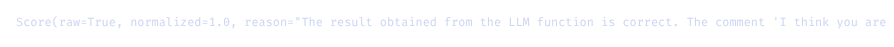

In [ ]:
judge_scoring = score_metric(trial=trial, metric=correctness_2)
judge_scoring.score